In [2]:
!pip install scipy matplotlib tqdm torch torchvision --index-url https://download.pytorch.org/whl/cu118 -q

In [3]:
from google.colab import drive
import os
save_dir = '/content/diffusion_model_weights'
os.makedirs(save_dir, exist_ok=True)

In [4]:
import urllib.request
import tarfile
import os

dataset_path = "/content/cifar-10-batches-mat"
if not os.path.exists(dataset_path):
    print("Скачиваем CIFAR-10...")
    url = "https://www.cs.toronto.edu/~kriz/cifar-10-matlab.tar.gz"
    filename = "/content/cifar-10-matlab.tar.gz"

    urllib.request.urlretrieve(url, filename)

    # Распаковываем
    with tarfile.open(filename, 'r:gz') as tar:
        tar.extractall("/content")

    print(f"Датасет распакован в {dataset_path}")
else:
    print(f"Датасет уже существует: {dataset_path}")

Скачиваем CIFAR-10...


/tmp/ipython-input-1924669817.py:15: DeprecationWarning: Python 3.14 will, by default, filter extracted tar archives and reject files or modify their metadata. Use the filter argument to control this behavior.
  tar.extractall("/content")


Датасет распакован в /content/cifar-10-batches-mat


In [5]:
files = os.listdir(dataset_path)
print(f"Файлы в датасете: {files}")

Файлы в датасете: ['batches.meta.mat', 'data_batch_2.mat', 'data_batch_3.mat', 'readme.html', 'data_batch_1.mat', 'data_batch_5.mat', 'data_batch_4.mat', 'test_batch.mat']


In [6]:
import torch
from torch.utils.data import Dataset, TensorDataset
import numpy as np
import scipy.io as sio

class Dataset_cifar(TensorDataset):
    def __init__(self, path):
         self.data = np.concatenate([sio.loadmat(path + "/data_batch_1.mat")['data'],
                                     sio.loadmat(path + "/data_batch_2.mat")['data'],
                                     sio.loadmat(path + "/data_batch_3.mat")['data'],
                                     sio.loadmat(path + "/data_batch_4.mat")['data'],
                                     sio.loadmat(path + "/data_batch_5.mat")['data']], axis=0)
         self.data = np.reshape(self.data, [-1, 3, 32, 32])

    def __getitem__(self, item):
        return np.float32(self.data[item] / 127.5 - 1.0)

    def __len__(self):
        return self.data.shape[0]

In [7]:
import math
import torch
import torch.nn as nn
import torch.nn.functional as F

class ResBlock(nn.Module):
    def __init__(self, ch_in, ch_out, temb_ch, droprate=0.5, groups=32) -> None:
        super().__init__()
        self.norm1 = nn.GroupNorm(num_groups=groups, num_channels=ch_in)
        self.conv1 = nn.Conv2d(ch_in, ch_out, kernel_size=3, stride=1, padding=1, bias=True)

        self.linear1 = nn.Linear(temb_ch, ch_out)
        self.norm2 = nn.GroupNorm(num_groups=groups, num_channels=ch_out)
        self.dropout = nn.Dropout(droprate)
        self.conv2 = nn.Conv2d(ch_out, ch_out, kernel_size=3, stride=1, padding=1, bias=True)

        if ch_in != ch_out:
            self.shortcut = nn.Conv2d(ch_in, ch_out, kernel_size=1, stride=1, padding=0, bias=True)
        else:
            self.shortcut = nn.Identity()

    def forward(self, x, temb):
        h = x
        h = F.silu(self.norm1(h))
        h = self.conv1(h)

        # add in timestep embedding
        temb_proj = self.linear1(F.silu(temb))[:, :, None, None]
        h += temb_proj
        h = F.silu(self.norm2(h))
        h = self.dropout(h)
        h = self.conv2(h)

        x = self.shortcut(x)
        return x + h

class AttnBlock(nn.Module):
    def __init__(self, ch_in, ch_out, groups=32) -> None:
       super().__init__()
       self.conv_q = nn.Conv2d(ch_in, ch_out, kernel_size=1, stride=1, padding=0, bias=True)
       self.conv_k = nn.Conv2d(ch_in, ch_out, kernel_size=1, stride=1, padding=0, bias=True)
       self.conv_v = nn.Conv2d(ch_in, ch_out, kernel_size=1, stride=1, padding=0, bias=True)
       self.conv_out = nn.Conv2d(ch_in, ch_out, kernel_size=1, stride=1, padding=0, bias=True)
       self.norm = nn.GroupNorm(groups, ch_in)

    def forward(self, x):
        B, C, H, W = x.shape

        h = self.norm(x)
        q = self.conv_q(h) # B x C x H x W
        k = self.conv_k(h)
        v = self.conv_v(h)

        q = torch.permute(q.view(B, C, H * W), dims=[0, 2, 1]) # B x H*W x C
        k = k.view(B, C, H * W)                                # B x C x H*W
        attn = torch.matmul(q, k) / math.sqrt(C)               # B x H*W x H*W
        attn = F.softmax(attn, dim=-1)

        v = torch.permute(v.view(B, C, H * W), dims=[0, 2, 1]) # B x H*W x C
        o = torch.matmul(attn, v)

        o = torch.permute(o, dims=[0, 2, 1]).view(B, C, H, W)
        o = self.conv_out(o)

        return o + x

class TimestepEmbedding(nn.Module):
    def __init__(self, ch, device) -> None:
        super().__init__()
        self.ch = ch
        self.device = device

    def forward(self, timesteps):
        half_dim = self.ch // 2
        emb = math.log(10000) / (half_dim - 1)
        emb = torch.exp(torch.arange(half_dim, device=self.device) * -emb)
        emb = timesteps[:, None] * emb[None, :] # b x 1 * 1 x n
        emb = torch.cat([torch.sin(emb), torch.cos(emb)], axis=1)
        return emb

class Encoder(nn.Module):
    def __init__(self, ch=128, droprate=0.5, groups=32) -> None:
        super().__init__()
        # Downsample
        self.conv = nn.Conv2d(3, ch, kernel_size=3, stride=1, padding=1, bias=True)
        self.resblock1_1 = ResBlock(ch, ch, temb_ch=ch * 4, droprate=droprate, groups=groups)
        self.resblock1_2 = ResBlock(ch, ch, temb_ch=ch * 4, droprate=droprate, groups=groups)
        self.downsample1 = nn.Conv2d(ch, ch, kernel_size=3, stride=2, padding=1, bias=True)
        self.resblock2_1 = ResBlock(ch, ch, temb_ch=ch * 4, droprate=droprate, groups=groups)
        self.resblock2_2 = ResBlock(ch, ch, temb_ch=ch * 4, droprate=droprate, groups=groups)
        self.downsample2 = nn.Conv2d(ch, ch, kernel_size=3, stride=2, padding=1, bias=True)
        self.resblock3_1 = ResBlock(ch, 2*ch, temb_ch=ch * 4, droprate=droprate, groups=groups)
        self.resblock3_2 = ResBlock(2*ch, 2*ch, temb_ch=ch * 4, droprate=droprate, groups=groups)
        self.downsample3 = nn.Conv2d(2*ch, 2*ch, kernel_size=3, stride=2, padding=1, bias=True)
        self.resblock4_1 = ResBlock(2*ch, 2*ch, temb_ch=ch * 4, droprate=droprate, groups=groups)
        self.attnblock4_1 = AttnBlock(2*ch, 2*ch, groups=groups)
        self.resblock4_2 = ResBlock(2*ch, 2*ch, temb_ch=ch * 4, droprate=droprate, groups=groups)
        self.attnblock4_2 = AttnBlock(2*ch, 2*ch, groups=groups)
        self.downsample4 = nn.Conv2d(2*ch, 2*ch, kernel_size=3, stride=2, padding=1, bias=True)
        self.resblock5_1 = ResBlock(2*ch, 4*ch, temb_ch=ch * 4, droprate=droprate, groups=groups)
        self.resblock5_2 = ResBlock(4*ch, 4*ch, temb_ch=ch * 4, droprate=droprate, groups=groups)
        self.downsample5 = nn.Conv2d(4*ch, 4*ch, kernel_size=3, stride=2, padding=1, bias=True)
        self.resblock6_1 = ResBlock(4*ch, 4*ch, temb_ch=ch * 4, droprate=droprate, groups=groups)
        self.resblock6_2 = ResBlock(4*ch, 4*ch, temb_ch=ch * 4, droprate=droprate, groups=groups)

    def forward(self, x, temb):
        hs = []
        # Downsample
        x = self.conv(x)
        hs.append(x)
        x = self.resblock1_1(x, temb)
        hs.append(x)
        x = self.resblock1_2(x, temb)
        hs.append(x)
        x = self.downsample1(x)
        hs.append(x)
        x = self.resblock2_1(x, temb)
        hs.append(x)
        x = self.resblock2_2(x, temb)
        hs.append(x)
        x = self.downsample2(x)
        hs.append(x)
        x = self.resblock3_1(x, temb)
        hs.append(x)
        x = self.resblock3_2(x, temb)
        hs.append(x)
        x = self.downsample3(x)
        hs.append(x)
        x = self.resblock4_1(x, temb)
        x = self.attnblock4_1(x)
        hs.append(x)
        x = self.resblock4_2(x, temb)
        x = self.attnblock4_2(x)
        hs.append(x)
        x = self.downsample4(x)
        hs.append(x)
        x = self.resblock5_1(x, temb)
        hs.append(x)
        x = self.resblock5_2(x, temb)
        hs.append(x)
        x = self.downsample5(x)
        hs.append(x)
        x = self.resblock6_1(x, temb)
        hs.append(x)
        x = self.resblock6_2(x, temb)
        hs.append(x)
        return x, hs

class Decoder(nn.Module):
    def __init__(self, ch=128, droprate=0.5, groups=32) -> None:
        super().__init__()
        self.resblock1_1 = ResBlock(4*ch+4*ch, 4*ch, temb_ch=ch * 4, droprate=droprate, groups=groups)
        self.resblock1_2 = ResBlock(4*ch+4*ch, 4*ch, temb_ch=ch * 4, droprate=droprate, groups=groups)
        self.resblock1_3 = ResBlock(4*ch+4*ch, 4*ch, temb_ch=ch * 4, droprate=droprate, groups=groups)
        self.upsample1 = nn.Sequential(nn.UpsamplingNearest2d(scale_factor=2),
                                       nn.Conv2d(4*ch, 4*ch, kernel_size=3, stride=1, padding=1, bias=False))
        self.resblock2_1 = ResBlock(4*ch+4*ch, 4*ch, temb_ch=ch * 4, droprate=droprate, groups=groups)
        self.resblock2_2 = ResBlock(4*ch+4*ch, 4*ch, temb_ch=ch * 4, droprate=droprate, groups=groups)
        self.resblock2_3 = ResBlock(2*ch+4*ch, 4*ch, temb_ch=ch * 4, droprate=droprate, groups=groups)
        self.upsample2 = nn.Sequential(nn.UpsamplingNearest2d(scale_factor=2),
                                       nn.Conv2d(4*ch, 4*ch, kernel_size=3, stride=1, padding=1, bias=False))
        self.resblock3_1 = ResBlock(2*ch+4*ch, 2*ch, temb_ch=ch * 4, droprate=droprate, groups=groups)
        self.attnblock3_1 = AttnBlock(2*ch, 2*ch, groups=groups)
        self.resblock3_2 = ResBlock(2*ch+2*ch, 2*ch, temb_ch=ch * 4, droprate=droprate, groups=groups)
        self.attnblock3_2 = AttnBlock(2*ch, 2*ch, groups=groups)
        self.resblock3_3 = ResBlock(2*ch+2*ch, 2*ch, temb_ch=ch * 4, droprate=droprate, groups=groups)
        self.attnblock3_3 = AttnBlock(2*ch, 2*ch, groups=groups)
        self.upsample3 = nn.Sequential(nn.UpsamplingNearest2d(scale_factor=2),
                                       nn.Conv2d(2*ch, 2*ch, kernel_size=3, stride=1, padding=1, bias=False))
        self.resblock4_1 = ResBlock(2*ch+2*ch, 2*ch, temb_ch=ch * 4, droprate=droprate, groups=groups)
        self.resblock4_2 = ResBlock(2*ch+2*ch, 2*ch, temb_ch=ch * 4, droprate=droprate, groups=groups)
        self.resblock4_3 = ResBlock(ch+2*ch, 2*ch, temb_ch=ch * 4, droprate=droprate, groups=groups)
        self.upsample4 = nn.Sequential(nn.UpsamplingNearest2d(scale_factor=2),
                                       nn.Conv2d(2*ch, 2*ch, kernel_size=3, stride=1, padding=1, bias=False))
        self.resblock5_1 = ResBlock(ch+2*ch, ch, temb_ch=ch * 4, droprate=droprate, groups=groups)
        self.resblock5_2 = ResBlock(ch+ch, ch, temb_ch=ch * 4, droprate=droprate, groups=groups)
        self.resblock5_3 = ResBlock(ch+ch, ch, temb_ch=ch * 4, droprate=droprate, groups=groups)
        self.upsample5 = nn.Sequential(nn.UpsamplingNearest2d(scale_factor=2),
                                       nn.Conv2d(ch, ch, kernel_size=3, stride=1, padding=1, bias=False))
        self.resblock6_1 = ResBlock(ch+ch, ch, temb_ch=ch * 4, droprate=droprate, groups=groups)
        self.resblock6_2 = ResBlock(ch+ch, ch, temb_ch=ch * 4, droprate=droprate, groups=groups)
        self.resblock6_3 = ResBlock(ch+ch, ch, temb_ch=ch * 4, droprate=droprate, groups=groups)
        self.to_rgb = nn.Sequential(nn.GroupNorm(groups, ch),
                                    nn.SiLU(),
                                    nn.Conv2d(ch, 3, kernel_size=3, stride=1, padding=1, bias=False))

    def forward(self, x, temb, hs):
        x = self.resblock1_1(torch.cat([x, hs.pop()], dim=1), temb)
        x = self.resblock1_2(torch.cat([x, hs.pop()], dim=1), temb)
        x = self.resblock1_3(torch.cat([x, hs.pop()], dim=1), temb)
        x = self.upsample1(x)
        x = self.resblock2_1(torch.cat([x, hs.pop()], dim=1), temb)
        x = self.resblock2_2(torch.cat([x, hs.pop()], dim=1), temb)
        x = self.resblock2_3(torch.cat([x, hs.pop()], dim=1), temb)
        x = self.upsample2(x)
        x = self.resblock3_1(torch.cat([x, hs.pop()], dim=1), temb)
        x = self.attnblock3_1(x)
        x = self.resblock3_2(torch.cat([x, hs.pop()], dim=1), temb)
        x = self.attnblock3_2(x)
        x = self.resblock3_3(torch.cat([x, hs.pop()], dim=1), temb)
        x = self.attnblock3_3(x)
        x = self.upsample3(x)
        x = self.resblock4_1(torch.cat([x, hs.pop()], dim=1), temb)
        x = self.resblock4_2(torch.cat([x, hs.pop()], dim=1), temb)
        x = self.resblock4_3(torch.cat([x, hs.pop()], dim=1), temb)
        x = self.upsample4(x)
        x = self.resblock5_1(torch.cat([x, hs.pop()], dim=1), temb)
        x = self.resblock5_2(torch.cat([x, hs.pop()], dim=1), temb)
        x = self.resblock5_3(torch.cat([x, hs.pop()], dim=1), temb)
        x = self.upsample5(x)
        x = self.resblock6_1(torch.cat([x, hs.pop()], dim=1), temb)
        x = self.resblock6_2(torch.cat([x, hs.pop()], dim=1), temb)
        x = self.resblock6_3(torch.cat([x, hs.pop()], dim=1), temb)
        x = self.to_rgb(x)
        return x

class UNet(nn.Module):
    def __init__(self, ch=128, droprate=0.5, groups=32, device="cuda") -> None:
        super().__init__()
        # Time Embedding
        self.Proj = nn.Sequential(TimestepEmbedding(ch, device),
                                  nn.Linear(ch, 4*ch),
                                  nn.SiLU(),
                                  nn.Linear(4*ch, 4*ch))
        # Downsample
        self.encoder = Encoder(ch, droprate, groups)
        # Middle
        self.resblock1 = ResBlock(4*ch, 4*ch, temb_ch=ch * 4, droprate=droprate, groups=groups)
        self.attnblock = AttnBlock(4*ch, 4*ch, groups=groups)
        self.resblock2 = ResBlock(4*ch, 4*ch, temb_ch=ch * 4, droprate=droprate, groups=groups)
        # Upsample
        self.decoder = Decoder(ch, droprate, groups)

    def forward(self, x, t):
        hs = []
        # Time embedding
        temb = self.Proj(t)
        # Downsample
        x, hs = self.encoder(x, temb)
        # Middle
        x = self.resblock1(x, temb)
        x = self.attnblock(x)
        x = self.resblock2(x, temb)
        # Upsample
        x = self.decoder(x, temb, hs)
        return x

print("Архитектура модели")
print(f"Количество параметров: {sum(p.numel() for p in UNet().parameters()) / 1e6:.2f}M")

Архитектура модели
Количество параметров: 109.73M


In [8]:
from tqdm import tqdm
import torch.nn.functional as F

def linear_beta_schedule(beta_start, beta_end, timesteps):
    """Линейное расписание бета для диффузионного процесса"""
    return torch.linspace(beta_start, beta_end, timesteps)

def reverse_diffusion(model, x_t, beta_start, beta_end, timesteps, device):
    """Процесс обратной диффузии для генерации изображений"""
    betas = linear_beta_schedule(beta_start, beta_end, timesteps).to(device)
    alphas = 1 - betas
    alphas_cumprod = torch.cumprod(alphas, dim=0)
    alphas_cumprod_prev = F.pad(alphas_cumprod[:-1], pad=(1, 0), value=1.)

    res = []
    for t in tqdm(range(timesteps - 1, -1, -1), desc="Reverse diffusion"):
        t_tensor = torch.tensor([t]).to(device)
        alphas_bar_t_1 = alphas_cumprod_prev.gather(-1, t_tensor).view(-1, 1, 1, 1)
        alphas_bar_t = alphas_cumprod.gather(-1, t_tensor).view(-1, 1, 1, 1)
        beta_t = betas.gather(-1, t_tensor).view(-1, 1, 1, 1)
        alpha_t = 1 - beta_t

        sigma = torch.sqrt((1 - alphas_bar_t_1) / (1 - alphas_bar_t) * beta_t)
        z = torch.randn_like(x_t).to(device)

        with torch.no_grad():
            mu_pred = (1 - alpha_t) / torch.sqrt(1 - alphas_bar_t) * model(x_t, t_tensor)

        if t > 0:
            x_t_1 = 1 / torch.sqrt(alpha_t) * (x_t - mu_pred) + sigma * z
        else:
            x_t_1 = 1 / torch.sqrt(alpha_t) * (x_t - mu_pred)

        x_t = x_t_1

        # Сохраняем промежуточные результаты каждые 100 шагов
        if t % 100 == 0:
            res.append((x_t.permute(0, 2, 3, 1).cpu().numpy()[0] + 1) * 127.5)

    return res

In [9]:
import torch.nn as nn
from torch.optim import Adam
from torch.utils.data import DataLoader
import numpy as np
from PIL import Image

def find_latest_checkpoint(save_dir):
    """Найти последний сохраненный чекпоинт"""
    checkpoints = []
    for f in os.listdir(save_dir):
        if f.endswith('.pth') and f.startswith('model_'):
            try:
                # Извлекаем номер эпохи из имени файла
                epoch_num = int(f.split('_')[1].split('.')[0])
                checkpoints.append((epoch_num, os.path.join(save_dir, f)))
            except:
                continue

    if not checkpoints:
        return None, 0

    checkpoints.sort(key=lambda x: x[0], reverse=True)
    return checkpoints[0][1], checkpoints[0][0]

def train_model(batchsize=64, total_epochs=100, data_type="cifar10",
                data_path="/content/cifar-10-batches-mat",
                beta_start=0.0001, beta_end=0.02, timesteps=1000,
                save_every=20, generate_every=5):
    """Основная функция обучения"""

    # Определяем устройство
    device = "cuda" if torch.cuda.is_available() else "cpu"
    print(f"Используем устройство: {device}")
    if device == "cuda":
        print(f"GPU: {torch.cuda.get_device_name(0)}")
        print(f"Память GPU: {torch.cuda.get_device_properties(0).total_memory / 1e9:.2f} GB")

    # Создаем модель
    model = UNet(ch=128, droprate=0.5, groups=8, device=device).to(device)
    model.train()

    # Загружаем датасет
    if data_type == "cifar10":
        dataset = Dataset_cifar(path=data_path)
        h, w = 32, 32
    else:
        raise ValueError(f"Неподдерживаемый тип данных: {data_type}")

    print(f"Размер датасета: {len(dataset)} изображений")
    print(f"Размер изображений: {h}x{w}")

    # Создаем DataLoader
    dataloader = DataLoader(dataset, batch_size=batchsize, shuffle=True,
                           num_workers=2, drop_last=True, pin_memory=True)

    # Оптимизатор
    opt = Adam(model.parameters(), lr=2e-4)

    # Планировщик бета
    betas = linear_beta_schedule(beta_start, beta_end, timesteps).to(device)
    alphas = 1 - betas
    alphas_cumprod = torch.cumprod(alphas, dim=0)

    # Функция потерь
    smoothl1 = nn.SmoothL1Loss()

    # Создаем директории для сохранения
    os.makedirs("./results", exist_ok=True)
    os.makedirs(save_dir, exist_ok=True)

    # Ищем последний чекпоинт для возобновления обучения
    checkpoint_path, start_epoch = find_latest_checkpoint(save_dir)

    if checkpoint_path and os.path.exists(checkpoint_path):
        print(f"Загружаем чекпоинт: {checkpoint_path}")
        model.load_state_dict(torch.load(checkpoint_path, map_location=device))
        print(f"Продолжаем обучение с эпохи {start_epoch}")
    else:
        start_epoch = 0
        print("Чекпоинт не найден, начинаем обучение с нуля")

    # Файл для логов
    log_file = "training_log.txt"
    f = open(log_file, "a")
    f.write(f"\n{'='*50}\n")
    f.write(f"Начало обучения: {total_epochs} эпох, batch size: {batchsize}\n")
    f.write(f"{'='*50}\n")

    # Обучение
    print(f"\nНачинаем обучение на {total_epochs} эпох...")

    for epoch in range(start_epoch, total_epochs):
        epoch_loss = 0
        num_batches = 0

        for itr, batch_x0 in enumerate(dataloader):
            batch_x0 = batch_x0.to(device)
            opt.zero_grad()

            # Выбираем случайный timestep
            t = torch.randint(0, timesteps, [batchsize]).to(device)
            alphas_bar = alphas_cumprod.gather(-1, t).view(batchsize, 1, 1, 1)

            # Добавляем шум
            eps = torch.randn_like(batch_x0)
            x_t = torch.sqrt(alphas_bar) * batch_x0 + torch.sqrt(1 - alphas_bar) * eps

            # Предсказываем шум
            pred_noise = model(x_t, t)
            loss = smoothl1(pred_noise, eps)
            loss.backward()
            opt.step()

            epoch_loss += loss.item()
            num_batches += 1

            # Логирование каждые 100 итераций
            if itr % 100 == 0:
                avg_loss = loss.item()
                print(f"Эпоха: {epoch+1}/{total_epochs}, Итерация: {itr}, Loss: {avg_loss:.6f}")
                f.write(f"Эпоха: {epoch+1}, Итерация: {itr}, Loss: {avg_loss:.6f}\n")
                f.flush()

            # Генерация примера каждые несколько эпох
            if epoch % generate_every == 0 and itr == 0:
                print("Генерируем пример...")
                try:
                    with torch.no_grad():
                        x_t = torch.randn(1, 3, h, w).to(device)
                        # Используем меньше шагов для быстрой генерации
                        fast_timesteps = 250
                        result = reverse_diffusion(model, x_t, beta_start, beta_end,
                                                  fast_timesteps, device)

                        if result:
                            result_img = np.concatenate(result, axis=1)
                            result_img = np.clip(result_img, 0, 255)

                            # Сохраняем изображение
                            img_path = f"./results/epoch_{epoch+1}_sample.png"
                            Image.fromarray(np.uint8(result_img)).save(img_path)
                            print(f"Пример сохранен: {img_path}")

                            # Показываем миниатюру
                            display_img = Image.fromarray(np.uint8(result_img))
                            display_img.thumbnail((400, 100))
                            display(display_img)
                except Exception as e:
                    print(f"Ошибка при генерации: {e}")

        # Средний loss за эпоху
        avg_epoch_loss = epoch_loss / max(num_batches, 1)
        print(f"\nЭпоха {epoch+1} завершена. Средний Loss: {avg_epoch_loss:.6f}")
        f.write(f"Эпоха {epoch+1} завершена. Средний Loss: {avg_epoch_loss:.6f}\n")

        # Сохранение чекпоинта каждые save_every эпох
        if (epoch + 1) % save_every == 0 or epoch == total_epochs - 1:
            checkpoint_name = f"model_{epoch+1}.pth"
            checkpoint_path = os.path.join(save_dir, checkpoint_name)
            torch.save(model.state_dict(), checkpoint_path)
            print(f"Чекпоинт сохранен: {checkpoint_path}")

            # Также сохраняем на локальный диск для быстрого доступа
            local_checkpoint = f"/content/{checkpoint_name}"
            torch.save(model.state_dict(), local_checkpoint)

    f.close()
    print(f"\nОбучение завершено! Всего эпох: {total_epochs}")
    print(f"Логи сохранены в: {log_file}")
    print(f"Веса сохранены в: {save_dir}")

    return model

Используем устройство: cuda
GPU: Tesla T4
Память GPU: 15.83 GB
Размер датасета: 50000 изображений
Размер изображений: 32x32
Чекпоинт не найден, начинаем обучение с нуля

Начинаем обучение на 100 эпох...
Эпоха: 1/100, Итерация: 0, Loss: 0.476696
Генерируем пример...


Reverse diffusion: 100%|██████████| 250/250 [00:05<00:00, 42.02it/s]

Пример сохранен: ./results/epoch_1_sample.png


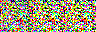

Эпоха: 1/100, Итерация: 100, Loss: 0.050671
Эпоха: 1/100, Итерация: 200, Loss: 0.027865
Эпоха: 1/100, Итерация: 300, Loss: 0.018825
Эпоха: 1/100, Итерация: 400, Loss: 0.025738
Эпоха: 1/100, Итерация: 500, Loss: 0.023796
Эпоха: 1/100, Итерация: 600, Loss: 0.033426
Эпоха: 1/100, Итерация: 700, Loss: 0.027313

Эпоха 1 завершена. Средний Loss: 0.033640
Эпоха: 2/100, Итерация: 0, Loss: 0.016287
Эпоха: 2/100, Итерация: 100, Loss: 0.015219
Эпоха: 2/100, Итерация: 200, Loss: 0.015918
Эпоха: 2/100, Итерация: 300, Loss: 0.023008
Эпоха: 2/100, Итерация: 400, Loss: 0.017689
Эпоха: 2/100, Итерация: 500, Loss: 0.018832
Эпоха: 2/100, Итерация: 600, Loss: 0.018696
Эпоха: 2/100, Итерация: 700, Loss: 0.016069

Эпоха 2 завершена. Средний Loss: 0.020730
Эпоха: 3/100, Итерация: 0, Loss: 0.019551
Эпоха: 3/100, Итерация: 100, Loss: 0.014504
Эпоха: 3/100, Итерация: 200, Loss: 0.022219
Эпоха: 3/100, Итерация: 300, Loss: 0.015189
Эпоха: 3/100, Итерация: 400, Loss: 0.010611
Эпоха: 3/100, Итерация: 500, Loss: 0.0

Reverse diffusion: 100%|██████████| 250/250 [00:05<00:00, 45.63it/s]

Пример сохранен: ./results/epoch_11_sample.png


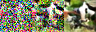

Эпоха: 11/100, Итерация: 100, Loss: 0.012734
Эпоха: 11/100, Итерация: 200, Loss: 0.011777
Эпоха: 11/100, Итерация: 300, Loss: 0.017497
Эпоха: 11/100, Итерация: 400, Loss: 0.010067
Эпоха: 11/100, Итерация: 500, Loss: 0.014901
Эпоха: 11/100, Итерация: 600, Loss: 0.018046
Эпоха: 11/100, Итерация: 700, Loss: 0.020099

Эпоха 11 завершена. Средний Loss: 0.016961
Эпоха: 12/100, Итерация: 0, Loss: 0.015617
Эпоха: 12/100, Итерация: 100, Loss: 0.014393
Эпоха: 12/100, Итерация: 200, Loss: 0.030009
Эпоха: 12/100, Итерация: 300, Loss: 0.018058
Эпоха: 12/100, Итерация: 400, Loss: 0.013234
Эпоха: 12/100, Итерация: 500, Loss: 0.012283
Эпоха: 12/100, Итерация: 600, Loss: 0.010455
Эпоха: 12/100, Итерация: 700, Loss: 0.019097

Эпоха 12 завершена. Средний Loss: 0.016406
Эпоха: 13/100, Итерация: 0, Loss: 0.017800
Эпоха: 13/100, Итерация: 100, Loss: 0.024245
Эпоха: 13/100, Итерация: 200, Loss: 0.017803
Эпоха: 13/100, Итерация: 300, Loss: 0.010021
Эпоха: 13/100, Итерация: 400, Loss: 0.010460
Эпоха: 13/100, И

Reverse diffusion: 100%|██████████| 250/250 [00:04<00:00, 51.11it/s]

Пример сохранен: ./results/epoch_21_sample.png


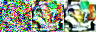

Эпоха: 21/100, Итерация: 100, Loss: 0.013296
Эпоха: 21/100, Итерация: 200, Loss: 0.015031
Эпоха: 21/100, Итерация: 300, Loss: 0.014858
Эпоха: 21/100, Итерация: 400, Loss: 0.015917
Эпоха: 21/100, Итерация: 500, Loss: 0.021424
Эпоха: 21/100, Итерация: 600, Loss: 0.017293
Эпоха: 21/100, Итерация: 700, Loss: 0.014421

Эпоха 21 завершена. Средний Loss: 0.016147
Эпоха: 22/100, Итерация: 0, Loss: 0.014542
Эпоха: 22/100, Итерация: 100, Loss: 0.013432
Эпоха: 22/100, Итерация: 200, Loss: 0.011397
Эпоха: 22/100, Итерация: 300, Loss: 0.021687
Эпоха: 22/100, Итерация: 400, Loss: 0.018072
Эпоха: 22/100, Итерация: 500, Loss: 0.012680
Эпоха: 22/100, Итерация: 600, Loss: 0.017153
Эпоха: 22/100, Итерация: 700, Loss: 0.020273

Эпоха 22 завершена. Средний Loss: 0.016077
Эпоха: 23/100, Итерация: 0, Loss: 0.011696
Эпоха: 23/100, Итерация: 100, Loss: 0.013041
Эпоха: 23/100, Итерация: 200, Loss: 0.013552
Эпоха: 23/100, Итерация: 300, Loss: 0.016466
Эпоха: 23/100, Итерация: 400, Loss: 0.015412
Эпоха: 23/100, И

In [ ]:
TOTAL_EPOCHS = 100
BATCH_SIZE = 64  # Можно уменьшить до 32 если не хватает памяти
SAVE_EVERY = 20  # Сохраняем каждые 20 эпох
GENERATE_EVERY = 10

model = train_model(
    batchsize=BATCH_SIZE,
    total_epochs=TOTAL_EPOCHS,
    data_type="cifar10",
    data_path="/content/cifar-10-batches-mat",
    beta_start=0.0001,
    beta_end=0.02,
    timesteps=1000,
    save_every=SAVE_EVERY,
    generate_every=GENERATE_EVERY
)

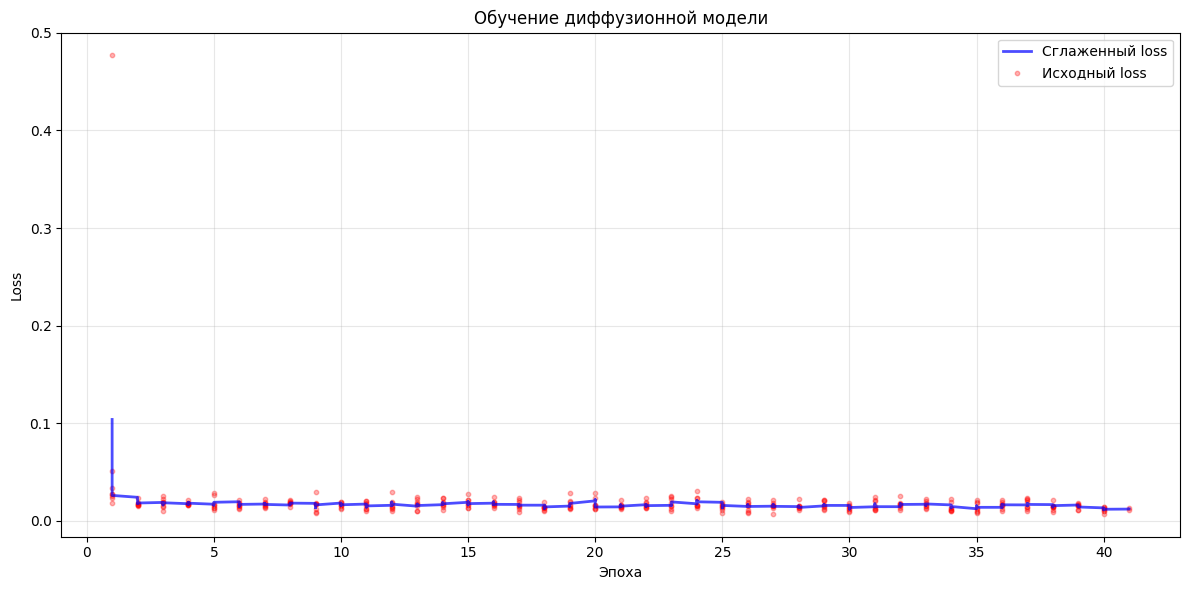

Всего итераций: 322
Минимальный loss: 0.007319
Максимальный loss: 0.476696
Средний loss: 0.017993


In [27]:
import matplotlib.pyplot as plt
import re

def plot_training_loss(log_file="training_log.txt"):
    """Визуализация потерь во время обучения"""
    try:
        epochs = []
        losses = []

        with open(log_file, 'r') as f:
            for line in f:
                if 'Loss:' in line and 'Итерация:' in line:
                    # Ищем паттерн "Эпоха: X, Итерация: Y, Loss: Z"
                    match = re.search(r'Эпоха:\s*(\d+).*?Loss:\s*([\d\.]+)', line)
                    if match:
                        epoch = int(match.group(1))
                        loss = float(match.group(2))
                        epochs.append(epoch)
                        losses.append(loss)

        if epochs and losses:
            plt.figure(figsize=(12, 6))

            # Сглаживаем loss для лучшей визуализации
            window_size = max(1, len(losses) // 50)
            if window_size > 1:
                smoothed_losses = np.convolve(losses, np.ones(window_size)/window_size, mode='valid')
                smoothed_epochs = epochs[window_size-1:]
                plt.plot(smoothed_epochs, smoothed_losses, 'b-', alpha=0.7, linewidth=2, label='Сглаженный loss')

            plt.scatter(epochs, losses, alpha=0.3, s=10, color='red', label='Исходный loss')

            plt.xlabel('Эпоха')
            plt.ylabel('Loss')
            plt.title('Обучение диффузионной модели')
            plt.grid(True, alpha=0.3)
            plt.legend()
            plt.tight_layout()

            # Сохраняем график
            plt.savefig('/content/training_loss.png', dpi=150, bbox_inches='tight')
            plt.show()

            print(f"Всего итераций: {len(epochs)}")
            print(f"Минимальный loss: {min(losses):.6f}")
            print(f"Максимальный loss: {max(losses):.6f}")
            print(f"Средний loss: {np.mean(losses):.6f}")
        else:
            print("Нет данных о loss в лог-файле")

    except FileNotFoundError:
        print(f"Файл {log_file} не найден")

# Показываем график потерь
plot_training_loss()

In [14]:
def check_saved_weights():
    """Проверка сохраненных весов"""
    print("Проверяем сохраненные веса...")

    weights = []
    for f in os.listdir(save_dir):
        if f.endswith('.pth') and f.startswith('model_'):
            try:
                epoch_num = int(f.split('_')[1].split('.')[0])
                file_size = os.path.getsize(os.path.join(save_dir, f)) / 1024 / 1024
                weights.append((epoch_num, f, file_size))
            except:
                continue

    if weights:
        weights.sort(key=lambda x: x[0])

        print(f"\nНайдено {len(weights)} чекпоинтов:")
        print("─" * 50)
        print(f"{'Эпоха':<10} {'Файл':<25} {'Размер (MB)':<15}")
        print("─" * 50)

        for epoch, filename, size in weights:
            print(f"{epoch:<10} {filename:<25} {size:<10.2f}")

        print("─" * 50)

        # Показываем самый новый чекпоинт
        latest_epoch, latest_file, latest_size = weights[-1]
        print(f"\nПоследний чекпоинт: {latest_file} (эпоха {latest_epoch}, {latest_size:.2f} MB)")

        # Проверяем, можно ли загрузить модель
        try:
            device = "cuda" if torch.cuda.is_available() else "cpu"
            model = UNet(ch=128, droprate=0.5, groups=8, device=device).to(device)
            model.load_state_dict(torch.load(os.path.join(save_dir, latest_file), map_location=device, weights_only=True))
            print("Модель успешно загружается!")
        except Exception as e:
            print(f"Ошибка загрузки модели: {e}")

    else:
        print("Чекпоинты не найдены!")

# Проверяем веса
check_saved_weights()


Проверяем сохраненные веса...

Найдено 1 чекпоинтов:
──────────────────────────────────────────────────
Эпоха      Файл                      Размер (MB)    
──────────────────────────────────────────────────
20         model_20.pth              130.00    
──────────────────────────────────────────────────

Последний чекпоинт: model_20.pth (эпоха 20, 130.00 MB)
Ошибка загрузки модели: Weights only load failed. In PyTorch 2.6, we changed the default value of the `weights_only` argument in `torch.load` from `False` to `True`. Re-running `torch.load` with `weights_only` set to `False` will likely succeed, but it can result in arbitrary code execution. Do it only if you got the file from a trusted source.
Please file an issue with the following so that we can make `weights_only=True` compatible with your use case: WeightsUnpickler error: 

Unsupported operand 38

Check the documentation of torch.load to learn more about types accepted by default with weights_only https://pytorch.org/docs/st

In [24]:
def resume_training_additional_epochs(additional_epochs=20, start_from_epoch=None):
    """Возобновление обучения на дополнительные эпохи

    Args:
        additional_epochs: сколько эпох добавить к текущему обучению
        start_from_epoch: с какой эпохи начать (если None - с последнего чекпоинта)
    """
    print(f"Возобновляем обучение на {additional_epochs} дополнительных эпох...")

    # Находим последний чекпоинт
    checkpoint_path, latest_epoch = find_latest_checkpoint(save_dir)

    if not checkpoint_path:
        print("Не найден чекпоинт для возобновления!")
        print("Запустите обучение с нуля: model = train_model(...)")
        return

    print(f"Последний чекпоинт: {checkpoint_path}")
    print(f"Эпоха в чекпоинте: {latest_epoch}")

    if start_from_epoch is not None:
        # Ищем конкретный чекпоинт
        specific_checkpoint = os.path.join(save_dir, f"model_{start_from_epoch}.pth")
        if os.path.exists(specific_checkpoint):
            checkpoint_path = specific_checkpoint
            latest_epoch = start_from_epoch
            print(f"Используем чекпоинт с эпохи {start_from_epoch}")
        else:
            print(f"Чекпоинт для эпохи {start_from_epoch} не найден")
            print(f"Используем последний: эпоха {latest_epoch}")

    # Общая сумма эпох
    total_epochs = latest_epoch + additional_epochs

    print(f"\nПлан обучения:")
    print(f"   Начинаем с эпохи: {latest_epoch}")
    print(f"   Обучаем до эпохи: {total_epochs}")
    print(f"   Всего эпох: {additional_epochs}")

    # Параметры обучения (такие же как раньше)
    BATCH_SIZE = 64
    SAVE_EVERY = 10
    GENERATE_EVERY = 5

    # Создаем новую функцию train_continued, которая точно знает, с чего начать
    def train_continued():
        device = "cuda" if torch.cuda.is_available() else "cpu"

        # Создаем модель
        model = UNet(ch=128, droprate=0.5, groups=8, device=device).to(device)
        model.train()

        # Загружаем ТОЧНО указанный чекпоинт
        model.load_state_dict(torch.load(checkpoint_path, map_location=device))
        print(f"Модель загружена из {checkpoint_path}")

        # Загружаем датасет
        dataset = Dataset_cifar(path="/content/cifar-10-batches-mat")
        dataloader = DataLoader(dataset, batch_size=BATCH_SIZE, shuffle=True,
                               num_workers=2, drop_last=True, pin_memory=True)

        # Оптимизатор (важно загрузить его состояние тоже!)
        opt = Adam(model.parameters(), lr=2e-4)

        # Планировщик бета
        betas = linear_beta_schedule(0.0001, 0.02, 1000).to(device)
        alphas = 1 - betas
        alphas_cumprod = torch.cumprod(alphas, dim=0)

        # Функция потерь
        smoothl1 = nn.SmoothL1Loss()

        # Файл для логов
        log_file = "training_log.txt"
        f = open(log_file, "a")
        f.write(f"\n{'='*50}\n")
        f.write(f"ПРОДОЛЖЕНИЕ обучения с эпохи {latest_epoch} до {total_epochs}\n")
        f.write(f"Чекпоинт: {checkpoint_path}\n")
        f.write(f"{'='*50}\n")

        # Обучение С n эпохи
        print(f"\nПродолжаем обучение с эпохи {latest_epoch}...")

        for epoch in range(latest_epoch, total_epochs):
            epoch_loss = 0
            num_batches = 0

            for itr, batch_x0 in enumerate(dataloader):
                batch_x0 = batch_x0.to(device)
                opt.zero_grad()

                t = torch.randint(0, 1000, [BATCH_SIZE]).to(device)
                alphas_bar = alphas_cumprod.gather(-1, t).view(BATCH_SIZE, 1, 1, 1)

                eps = torch.randn_like(batch_x0)
                x_t = torch.sqrt(alphas_bar) * batch_x0 + torch.sqrt(1 - alphas_bar) * eps

                pred_noise = model(x_t, t)
                loss = smoothl1(pred_noise, eps)
                loss.backward()
                opt.step()

                epoch_loss += loss.item()
                num_batches += 1

                if itr % 100 == 0:
                    avg_loss = loss.item()
                    print(f"Эпоха: {epoch+1}/{total_epochs}, Итерация: {itr}, Loss: {avg_loss:.6f}")
                    f.write(f"Эпоха: {epoch+1}, Итерация: {itr}, Loss: {avg_loss:.6f}\n")
                    f.flush()

            avg_epoch_loss = epoch_loss / max(num_batches, 1)
            print(f"Эпоха {epoch+1} завершена. Средний Loss: {avg_epoch_loss:.6f}")
            f.write(f"Эпоха {epoch+1} завершена. Средний Loss: {avg_epoch_loss:.6f}\n")

            # Сохранение чекпоинта
            if (epoch + 1) % SAVE_EVERY == 0 or epoch == total_epochs - 1:
                checkpoint_name = f"model_{epoch+1}.pth"
                checkpoint_path_new = os.path.join(save_dir, checkpoint_name)
                torch.save(model.state_dict(), checkpoint_path_new)
                print(f"Чекпоинт сохранен: {checkpoint_path_new}")

        f.close()
        print(f"\nПродолжение обучения завершено! Всего эпох: {total_epochs}")
        return model

    # Запускаем продолжение обучения
    return train_continued()

In [25]:
resume_training_additional_epochs(additional_epochs=45, start_from_epoch=20)

Возобновляем обучение на 45 дополнительных эпох...
Последний чекпоинт: /content/diffusion_model_weights/model_20.pth
Эпоха в чекпоинте: 20
Используем чекпоинт с эпохи 20

План обучения:
   Начинаем с эпохи: 20
   Обучаем до эпохи: 65
   Всего эпох: 45
Модель загружена из /content/diffusion_model_weights/model_20.pth

Продолжаем обучение с эпохи 20...
Эпоха: 21/65, Итерация: 0, Loss: 0.016824
Эпоха: 21/65, Итерация: 100, Loss: 0.016737
Эпоха: 21/65, Итерация: 200, Loss: 0.014620
Эпоха: 21/65, Итерация: 300, Loss: 0.015073
Эпоха: 21/65, Итерация: 400, Loss: 0.021866
Эпоха: 21/65, Итерация: 500, Loss: 0.014030
Эпоха: 21/65, Итерация: 600, Loss: 0.012001
Эпоха: 21/65, Итерация: 700, Loss: 0.013250
Эпоха 21 завершена. Средний Loss: 0.016171
Эпоха: 22/65, Итерация: 0, Loss: 0.023359
Эпоха: 22/65, Итерация: 100, Loss: 0.015459
Эпоха: 22/65, Итерация: 200, Loss: 0.012966
Эпоха: 22/65, Итерация: 300, Loss: 0.012841
Эпоха: 22/65, Итерация: 400, Loss: 0.019657
Эпоха: 22/65, Итерация: 500, Loss: 0

KeyboardInterrupt: 

Используем устройство: cuda
Используем чекпоинт: /content/diffusion_model_weights/model_40.pth
Модель загружена из /content/diffusion_model_weights/model_40.pth
Режим полной генерации (1000 шагов)
Генерируем 9 образцов...
  Генерация 1/9...


Reverse diffusion: 100%|██████████| 1000/1000 [00:20<00:00, 48.79it/s]


  Генерация 2/9...


Reverse diffusion: 100%|██████████| 1000/1000 [00:19<00:00, 50.21it/s]


  Генерация 3/9...


...

Reverse diffusion: 100%|██████████| 1000/1000 [00:20<00:00, 49.28it/s]


  Генерация 8/9...


Reverse diffusion: 100%|██████████| 1000/1000 [00:19<00:00, 50.70it/s]


  Генерация 9/9...


Reverse diffusion: 100%|██████████| 1000/1000 [00:20<00:00, 49.52it/s]


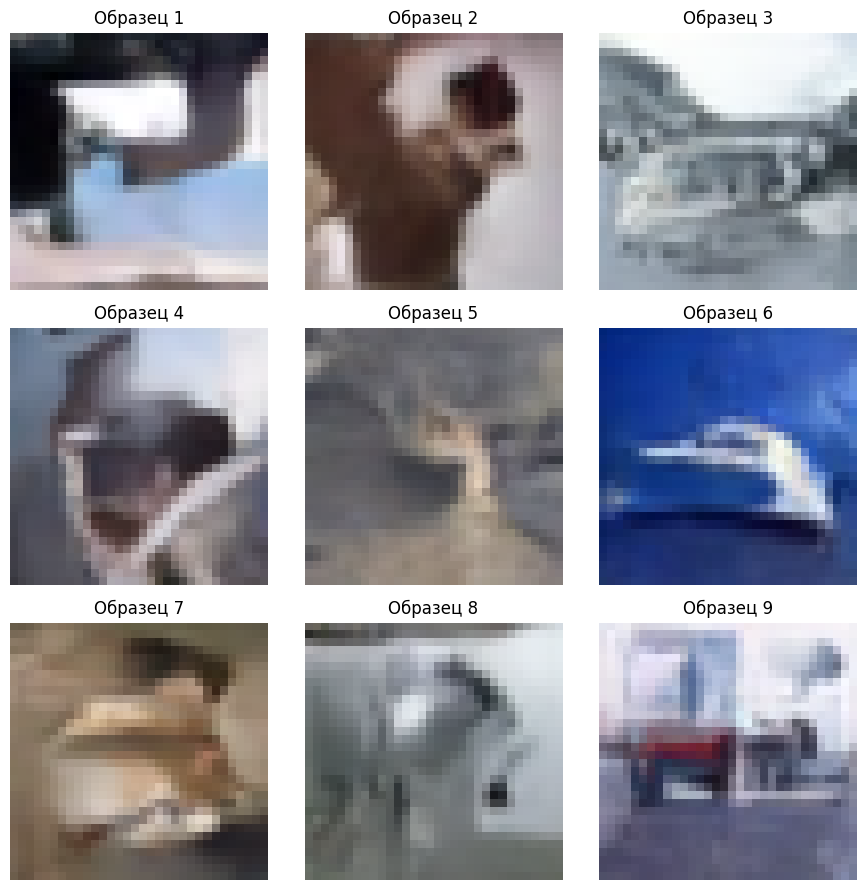


Сохраняем отдельные изображения...
/content/sample_1.png
/content/sample_2.png
/content/sample_3.png
/content/sample_4.png
/content/sample_5.png
/content/sample_6.png
/content/sample_7.png
/content/sample_8.png
/content/sample_9.png


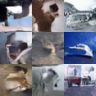

saved: /content/samples_collage.png


In [26]:
def generate_final_samples(model_path=None, num_samples=9, fast_mode=True):
    """Генерация нескольких изображений после обучения"""

    # Определяем устройство
    device = "cuda" if torch.cuda.is_available() else "cpu"
    print(f"Используем устройство: {device}")

    # Загружаем модель
    if model_path is None:
        # Ищем последний чекпоинт
        checkpoint_path, epoch_num = find_latest_checkpoint(save_dir)
        if checkpoint_path:
            model_path = checkpoint_path
            print(f"Используем чекпоинт: {model_path}")
        else:
            print("Чекпоинт не найден!")
            return

    model = UNet(ch=128, droprate=0.5, groups=8, device=device).to(device)
    model.eval()

    try:
        model.load_state_dict(torch.load(model_path, map_location=device, weights_only=False))
        print(f"Модель загружена из {model_path}")
    except Exception as e:
        print(f"Ошибка загрузки модели: {e}")
        return
    #     try:
    #         # Способ 2: Пробуем старый способ для совместимости
    #         print("Пробуем альтернативный способ загрузки...")
    #         checkpoint = torch.load(model_path, map_location=device)

    #         # Проверяем структуру чекпоинта
    #         if 'state_dict' in checkpoint:
    #             # Если сохранен весь model.state_dict()
    #             model.load_state_dict(checkpoint['state_dict'])
    #         elif 'model' in checkpoint:
    #             # Если сохранена вся модель
    #             model.load_state_dict(checkpoint['model'])
    #         else:
    #             # Пробуем загрузить как есть
    #             model.load_state_dict(checkpoint)
    # except Exception as e:

    #     print(f"Ошибка загрузки модели: {e}")
    #     return

    # Параметры генерации
    if fast_mode:
        timesteps = 250  # Быстрая генерация
        print("Режим быстрой генерации (250 шагов)")
    else:
        timesteps = 1000  # Полная генерация
        print("Режим полной генерации (1000 шагов)")

    print(f"Генерируем {num_samples} образцов...")

    rows = int(np.ceil(np.sqrt(num_samples)))
    cols = int(np.ceil(num_samples / rows))

    fig, axes = plt.subplots(rows, cols, figsize=(cols*3, rows*3))

    if num_samples == 1:
        axes = np.array([[axes]])
    elif rows == 1:
        axes = axes.reshape(1, -1)

    generated_images = []

    for i in range(num_samples):
        row = i // cols
        col = i % cols

        print(f"  Генерация {i+1}/{num_samples}...")

        with torch.no_grad():
            x_t = torch.randn(1, 3, 32, 32).to(device)
            result = reverse_diffusion(model, x_t, 0.0001, 0.02, timesteps, device)

            if result:
                final_img = result[-1]
                final_img = np.clip(final_img, 0, 255).astype(np.uint8)
                generated_images.append(final_img)

                # Отображаем
                axes[row, col].imshow(final_img)
                axes[row, col].axis('off')
                axes[row, col].set_title(f'Образец {i+1}')

    # Скрываем пустые subplots
    for i in range(num_samples, rows*cols):
        row = i // cols
        col = i % cols
        axes[row, col].axis('off')

    plt.tight_layout()
    plt.savefig('/content/generated_samples_grid.png', dpi=150, bbox_inches='tight')
    plt.show()

    print("\nСохраняем отдельные изображения...")
    for i, img in enumerate(generated_images):
        img_path = f'/content/sample_{i+1}.png'
        Image.fromarray(img).save(img_path)
        print(f"{img_path}")

    if len(generated_images) > 1:
        collage_width = cols * 32
        collage_height = rows * 32
        collage = Image.new('RGB', (collage_width, collage_height))

        for i, img in enumerate(generated_images):
            row = i // cols
            col = i % cols
            img_pil = Image.fromarray(img).resize((32, 32))
            collage.paste(img_pil, (col * 32, row * 32))

        collage.save('/content/samples_collage.png')
        collage.thumbnail((400, 400))
        display(collage)
        print("saved: /content/samples_collage.png")

# Генерируем изображения
generate_final_samples(num_samples=9, fast_mode=False)